## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Sec 002 Spring 2025)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**89**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpreting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructingand evaluating clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

&#9989;&nbsp; **Question 1 (30 points)**: In this question, you're going to investigate the [Lorenz system](https://en.wikipedia.org/wiki/Lorenz_system), that models a dynamical system in which a very small change in initial conditions creates a significantly larger consequences. This phenomenon is known as the `butterfly effect`, and has been used in [weather modeling](https://en.wikipedia.org/wiki/Numerical_weather_prediction). We can model this system with the following equations:

$$ \frac{dx}{dt} = a(y-x) $$
$$ \frac{dy}{dt} = x(b-z) - y $$
$$ \frac{dz}{dt} = xy-cz $$

where  x is proportional to the rate of convection, y to the horizontal temperature variation, and z to the vertical temperature variation. The constants $a, b$, and $c$ are system parameters that relate to certain physical dimensions.  Given that we're talking about the change of weather over time, we assume will use **days** as our unit of time, $t$. This means that, for example, $t = 2$ would be _2 days_. 

Solve this dynamical system using `solve_ivp`, with parameter values $a= 1, b= 100$, and $c=\frac{9}{10}$. Assume the following initial conditions:

* $x(0) = 2$
* $y(0) = 3$
* $z(0) = -4$

Evolve the model for $15$ days using a timestep of $\Delta t = 0.001$ days.

**Code you need to write to solve this problem**:
* A function that takes in a set of time values as well as the current values for $x$, $y$, and $z$ and **returns** the derivatives for each variable, $\frac{dx}{dt}$, $\frac{dy}{dt}$, and $\frac{dz}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.
* A set of variables for storing your initial conditions, $x_0$, $y_0$, and $z_0$, set to the correct initial values.
* A variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.
* Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. 
* Code that unpacks the solution so that you can plot it.

**Note**: you will need the "`args`" argument for `solve_ivp` because model parameters need to be specified, as indicated above.

In [ ]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


In [36]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import numpy as np

# Define the derivatives function
def derivs(t, vals, a,b,c):
    x, y, z = vals
    dxdt = a*(y-x)
    dydt = x*(b-z)-y
    dzdt = x*y - c*z
    return dxdt, dydt, dzdt

# Solve the system
x0 = 2
y0 = 3
z0 = -4
ICs = [x0, y0, z0]
t = np.arange(0, 15, 0.001)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t, args=[1,100,9/10])
x = sol.y[0,:]
y = sol.y[1,:]
z = sol.y[2,:]
print(x)

# RUBRIC
# 5 points for correct time array: spacing, length, etc
# 5 points for correct syntax of solve_ivp()
# 5 points for correct retrieval of solutions for x, y and z compartments
# 5 points for correct use of initial values
# 5 points for derivatives function
# 5 points for printing
# Total of 30 points

[2.         2.00110193 2.00240753 ... 9.4170438  9.41701059 9.41697938]


&#9989;&nbsp; **Question 2 (10 points)**:
Now that you have a solution to the model, make a single plot that displays the evolution of all three variables, $x$, $y$, and $z$ as a function time. Each line should be a different color and your plot should contain axes labels, a title, and a legend.

If all goes well, you should end up with something that looks like this:
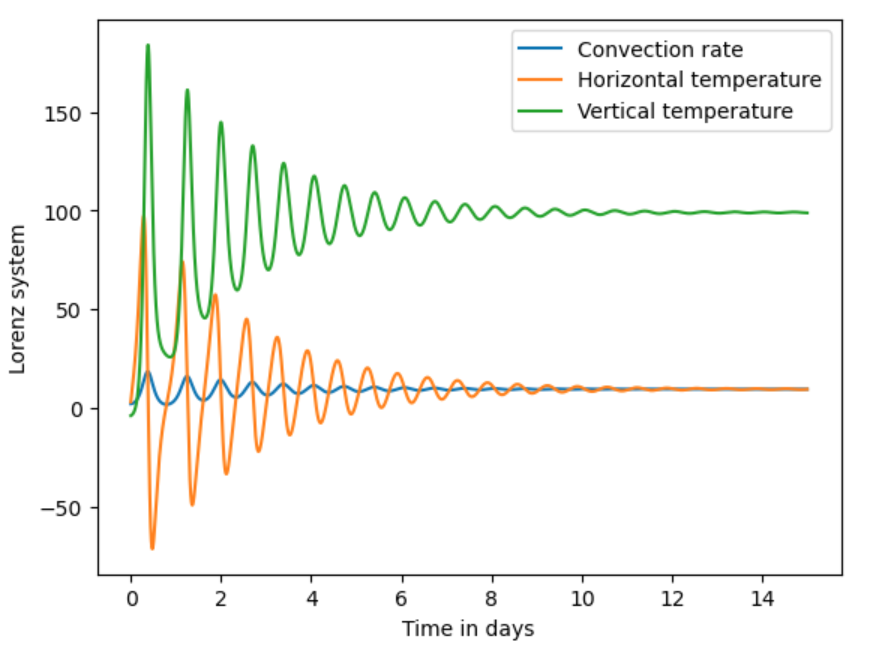

In [3]:
# put your code here

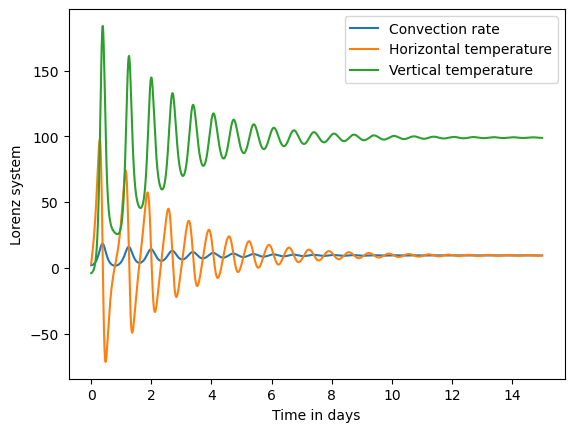

In [12]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt


plt.figure(1)
plt.plot(t,x,label="Convection rate")
plt.plot(t,y,label="Horizontal temperature")
plt.plot(t,z,label="Vertical temperature")
plt.xlabel("Time in days")
plt.ylabel("Lorenz system")
plt.legend()
plt.savefig("Quiz4_Q2.png")

#RUBRIC
# 2 points each for x, y, and z plots. Total of 6
# 2 points for legend
# 2 points for axis labels
#Total of 10 points

---
## Part 2: Data Visualization (39 points)
Below are six different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, **choose three** visualizations to analyze below:

<table>
  <tr>
    <th style="width:30%">Visualization 1</th>
    <th style="width:25%">Visualization 2</th>
    <th>Visualization 3</th>
  </tr>
  <tr>
    <td><img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/badGraphic.png?raw=true" /></td>
    <td><img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (6).png?raw=true" width="100%"/> </td>
    <td><img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.32.57 PM.png?raw=true" /></td>
  </tr>
  <tr>
    <th>Visualization 4</th>
    <th>Visualization 5</th>
    <th>Visualization 6</th>
  </tr>
  <tr>
    <td><img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (2).png?raw=true" /></td>
    <td><img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (9).png?raw=true" /> </td>
    <td><img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/whimsical_squid.png?raw=true" /></td>
  </tr>
</table>

For each visualization of your choosing, answer the following questions:

	(1) Does the plot tell a story? If so, what is it saying? (6 pts per visualization)
    (2) Does it use multi-variable data? (3 pts per visualization)
	(3) Is there excessive white space or cluttering? (1 pts per visualization)
	(4) Are plot components appropriately labeled (legend, axes, title, etc)? (1 pt per visualization)
	(5) Describe one way the plot could be improved. (2 pts per visualization)


### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations and add your favorite bad visualizations!



**Answers to questions about first visualization of your choosing:**

 <font size="+3">&#9998;</font>
 1. _answer_
 2.  _answer_
 3.   _answer_
 4.    _answer_
 5. _answer_
 6.  _answer_


**Answers to questions about second visualization of your choosing:**

 <font size="+3">&#9998;</font> 
 
 1. _answer_
 2.  _answer_
 3.   _answer_
 4.    _answer_
 5. _answer_
 6.  _answer_


**Answers to questions about third visualization of your choosing:**

 <font size="+3">&#9998;</font>
 1. _answer_
 2.  _answer_
 3.   _answer_
 4.    _answer_
 5. _answer_
 6.  _answer_


---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #4, and upload it there.